# Black-Litterman allocation

The Black-Litterman method is a very powerful way of converting your views on asset returns, along with your uncertainty in these views, into a portfolio.

For a description of the theory, please read the [documentation page](https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html) and the links therein.

In this recipe, we will cover:

- Downloading data for the Black-Litterman method
- Constructing the prior return vector based on market equilibrium
- Two ways of constructing the uncertainty matrix
- Combining Black-Litterman with mean-variance optimization

## Downloading data

In addition to price data, constructing a market prior requires market-caps.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/PyPortfolio/PyPortfolioOpt/blob/main/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)
    
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/pyportfolio/pyportfolioopt/blob/master/cookbook/4-Black-Litterman-Allocation.ipynb)

In [55]:
!pip install pandas numpy matplotlib PyPortfolioOpt
import os
if not os.path.isdir('data'):
    os.system('git clone https://github.com/pyportfolio/pyportfolioopt.git')
    os.chdir('PyPortfolioOpt/cookbook')


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt.data.data_loader import load_stockdata, load_marketcaps

In [57]:
tickers = ["MSFT", "AMZN", "NAT", "BAC", "DPZ", "DIS", "KO", "MCD", "COST", "SBUX"]

In [58]:
prices = load_stockdata(tickers=tickers)
prices

,MSFT,AMZN,NAT,BAC,DPZ,DIS,KO,MCD,COST,SBUX
date,,,,,,,,,,
2021-01-01,131.295831,296.721734,232.401545,243.061192,232.251792,226.714336,205.824532,127.745580,51.380529,79.898561
2021-01-04,130.283265,296.899868,238.671610,241.727036,231.373707,226.031949,206.444122,127.140749,50.781585,79.547343
2021-01-05,134.250739,297.407284,245.713955,240.661725,230.162426,225.185988,203.873733,130.591434,50.790121,80.452200
2021-01-06,136.706214,294.030801,246.661663,239.795313,236.112588,230.128279,201.033590,131.184790,51.596978,81.184599
2021-01-07,139.795039,297.587133,244.974456,239.231142,232.953930,230.539394,200.653953,133.182859,52.020537,81.299196
...,...,...,...,...,...,...,...,...,...,...
2023-11-20,177.462826,464.912592,672.301063,387.472514,261.603321,376.332974,101.317900,168.578776,68.069208,67.267696
2023-11-21,176.200688,467.773657,671.947264,384.432159,260.850804,369.415006,101.433351,173.110283,67.963309,67.056869
2023-11-22,177.577507,471.595354,672.801908,387.754766,262.512227,363.789606,101.905173,171.934122,66.529335,66.072427


In [59]:
market_prices = load_stockdata(tickers=["SPY"])
market_prices.head()

,SPY
date,
2021-01-01,228.311197
2021-01-04,227.755471
2021-01-05,231.789748
2021-01-06,229.689287
2021-01-07,231.250131


In [60]:
mcaps = load_marketcaps(tickers=tickers)
mcaps

{'AMZN': 1199323675973,
 'BAC': 316257187682,
 'COST': 120876806275,
 'DIS': 1204224448427,
 'DPZ': 1417604792703,
 'KO': 370891997157,
 'MCD': 866730312191,
 'MSFT': 586002134695,
 'NAT': 1225646524971,
 'SBUX': 914859618512}

## Constructing the prior

In [61]:
import pypfopt
pypfopt.__version__

'1.6.0'

In [62]:
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, plotting

S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
delta = black_litterman.market_implied_risk_aversion(market_prices)
delta

np.float64(3.137363404997928)

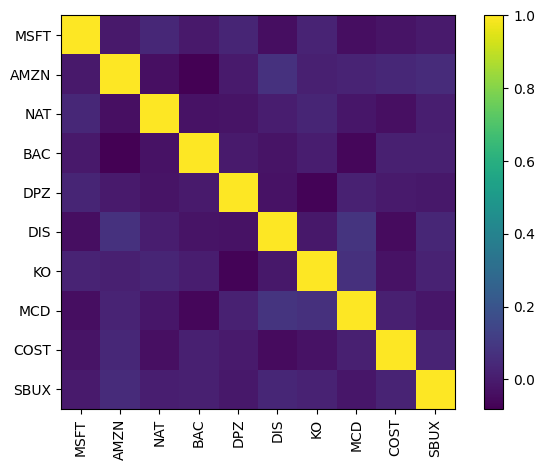

In [63]:
plotting.plot_covariance(S, plot_correlation=True);

In [64]:
market_prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)
market_prior

MSFT    0.025293
AMZN    0.022358
NAT     0.046473
BAC    -0.000086
DPZ     0.013902
DIS     0.034530
KO      0.012965
MCD     0.031959
COST    0.000844
SBUX    0.015641
dtype: float64

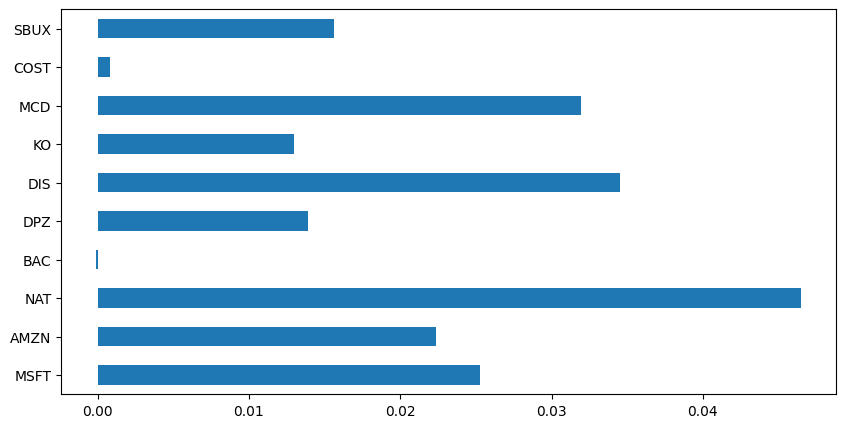

In [65]:
market_prior.plot.barh(figsize=(10,5));

## Views

In the BL method, views are specified via the matrix P (picking matrix) and the vector Q. Q contains the magnitude of each view, while P maps the views to the assets they belong to. 

If you are providing **absolute views** (i.e a return estimate for each asset), you don't have to worry about P and Q, you can just pass your views as a dictionary.

In [66]:
# You don't have to provide views on all the assets
viewdict = {
    "AMZN": 0.10,
    "BAC": 0.30,
    "COST": 0.05,
    "DIS": 0.05,
    "DPZ": 0.20,
    "KO": -0.05,  # I think Coca-Cola will go down 5%
    "MCD": 0.15,
    "MSFT": 0.10,
    "NAT": 0.50,  # but low confidence, which will be reflected later
    "SBUX": 0.10
}

bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict)

Black-Litterman also allows for relative views, e.g you think asset A will outperform asset B by 10%. If you'd like to incorporate these, you will have to build P and Q yourself. An explanation for this is given in the [docs](https://pyportfolioopt.readthedocs.io/en/latest/BlackLitterman.html#views).

## View confidences

In this section, we provide two ways that you may wish to construct the uncertainty matrix. The first is known as Idzorek's method. It allows you to specify a vector/list of percentage confidences.

In [67]:
confidences = [
    0.6,
    0.4,
    0.2,
    0.5,
    0.7, # confident in dominos
    0.7, # confident KO will do poorly
    0.7, 
    0.5,
    0.1,
    0.4
]

In [68]:
bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict, omega="idzorek", view_confidences=confidences)

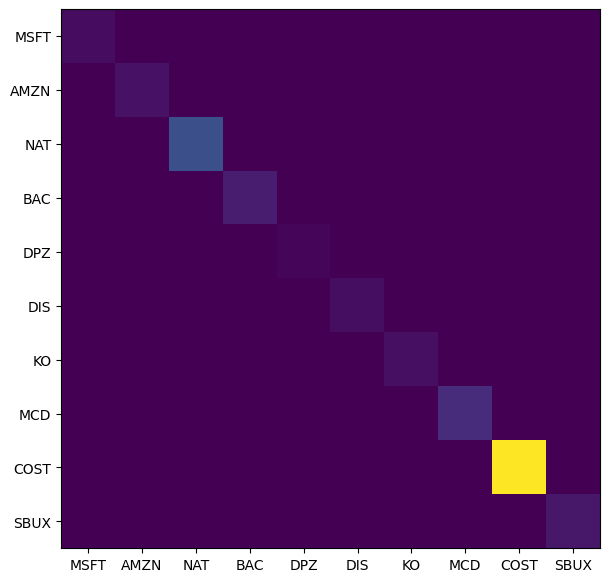

In [69]:
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(bl.omega)

# We want to show all ticks...
ax.set_xticks(np.arange(len(bl.tickers)))
ax.set_yticks(np.arange(len(bl.tickers)))

ax.set_xticklabels(bl.tickers)
ax.set_yticklabels(bl.tickers)
plt.show()

In [70]:
np.diag(bl.omega)

array([0.00150597, 0.00214868, 0.01107929, 0.0034324 , 0.00059481,
       0.00162626, 0.00189831, 0.00573102, 0.04536189, 0.00295041])

Note how NAT, which we gave the lowest confidence, also has the highest uncertainty.

Instead of inputting confidences, we can calculate the uncertainty matrix directly by specifying 1 standard deviation confidence intervals, i.e bounds which we think will contain the true return 68% of the time. This may be easier than coming up with somewhat arbitrary percentage confidences

In [71]:
intervals = [
    (0, 0.25),
    (0.1, 0.4),
    (-0.1, 0.15),
    (-0.05, 0.1),
    (0.15, 0.25),
    (-0.1, 0),
    (0.1, 0.2),
    (0.08, 0.12),
    (0.1, 0.9),
    (0, 0.3)
]

In [72]:
variances = []
for lb, ub in intervals:
    sigma = (ub - lb)/2
    variances.append(sigma ** 2)

print(variances)
omega = np.diag(variances)

[0.015625, 0.022500000000000006, 0.015625, 0.0056250000000000015, 0.0025000000000000005, 0.0025000000000000005, 0.0025000000000000005, 0.00039999999999999986, 0.16000000000000003, 0.0225]


## Posterior estimates

Given the inputs, we can compute a posterior estimate of returns


In [73]:
# We are using the shortcut to automatically compute market-implied prior
bl = BlackLittermanModel(S, pi="market", market_caps=mcaps, risk_aversion=delta,
                        absolute_views=viewdict, omega=omega)

In [74]:
# Posterior estimate of returns
ret_bl = bl.bl_returns()
ret_bl

MSFT    0.095047
AMZN    0.031365
NAT     0.055978
BAC     0.013864
DPZ     0.082278
DIS     0.041040
KO     -0.025142
MCD     0.105681
COST    0.008812
SBUX    0.021346
dtype: float64

We can visualise how this compares to the prior and our views:

In [75]:
rets_df = pd.DataFrame([market_prior, ret_bl, pd.Series(viewdict)], 
             index=["Prior", "Posterior", "Views"]).T
rets_df

,Prior,Posterior,Views
MSFT,0.025293,0.095047,0.10
AMZN,0.022358,0.031365,0.10
NAT,0.046473,0.055978,0.50
BAC,-0.000086,0.013864,0.30
DPZ,0.013902,0.082278,0.20
DIS,0.034530,0.041040,0.05
KO,0.012965,-0.025142,-0.05
MCD,0.031959,0.105681,0.15
COST,0.000844,0.008812,0.05
SBUX,0.015641,0.021346,0.10


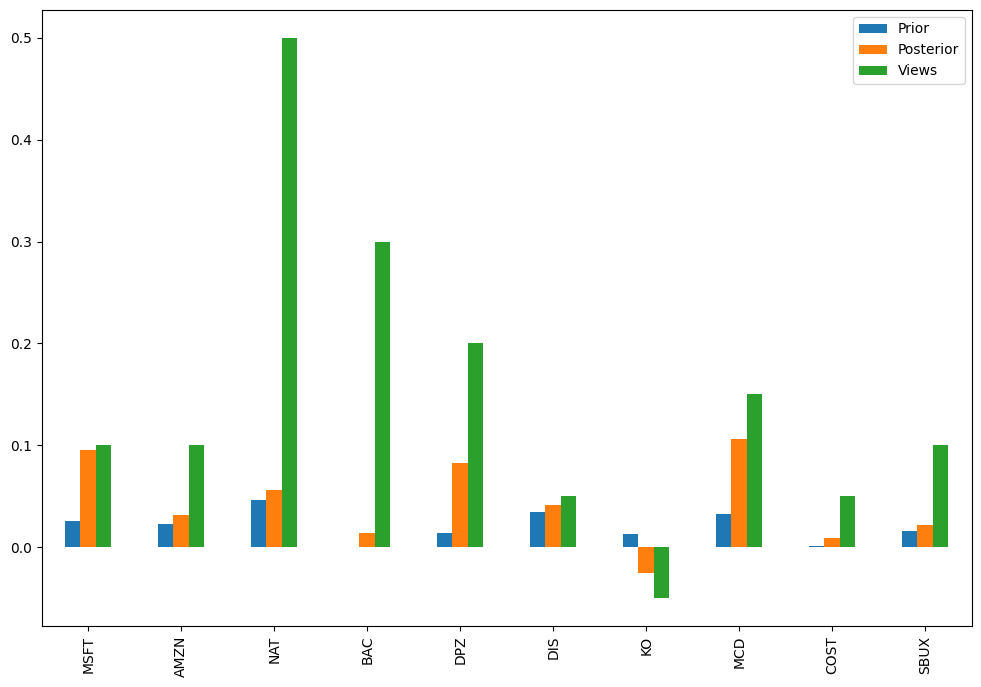

In [76]:
rets_df.plot.bar(figsize=(12,8));

Notice that the posterior is often between the prior and the views. This supports the fact that the BL method is essentially a Bayesian weighted-average of the prior and views, where the weight is determined by the confidence.

A similar but less intuitive procedure can be used to produce the posterior covariance estimate:

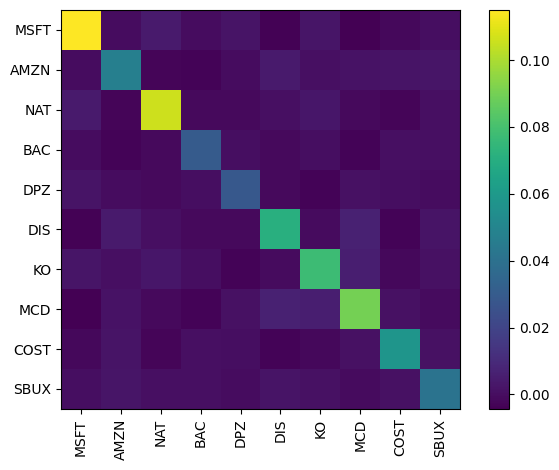

In [77]:
S_bl = bl.bl_cov()
plotting.plot_covariance(S_bl);

## Portfolio allocation

Now that we have constructed our Black-Litterman posterior estimate, we can proceed to use any of the optimizers discussed in previous recipes.

In [78]:
from pypfopt import EfficientFrontier, objective_functions

In [79]:
ef = EfficientFrontier(ret_bl, S_bl)
ef.add_objective(objective_functions.L2_reg)
ef.max_sharpe()
weights = ef.clean_weights()
weights

C:\Users\shuvam\sparkle\pyportfolio\pypfopt\efficient_frontier\efficient_frontier.py:281: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


OrderedDict([('MSFT', 0.20167),
             ('AMZN', 0.07034),
             ('NAT', 0.11937),
             ('BAC', 0.03304),
             ('DPZ', 0.18847),
             ('DIS', 0.08964),
             ('KO', 0.0),
             ('MCD', 0.22902),
             ('COST', 0.02021),
             ('SBUX', 0.04825)])

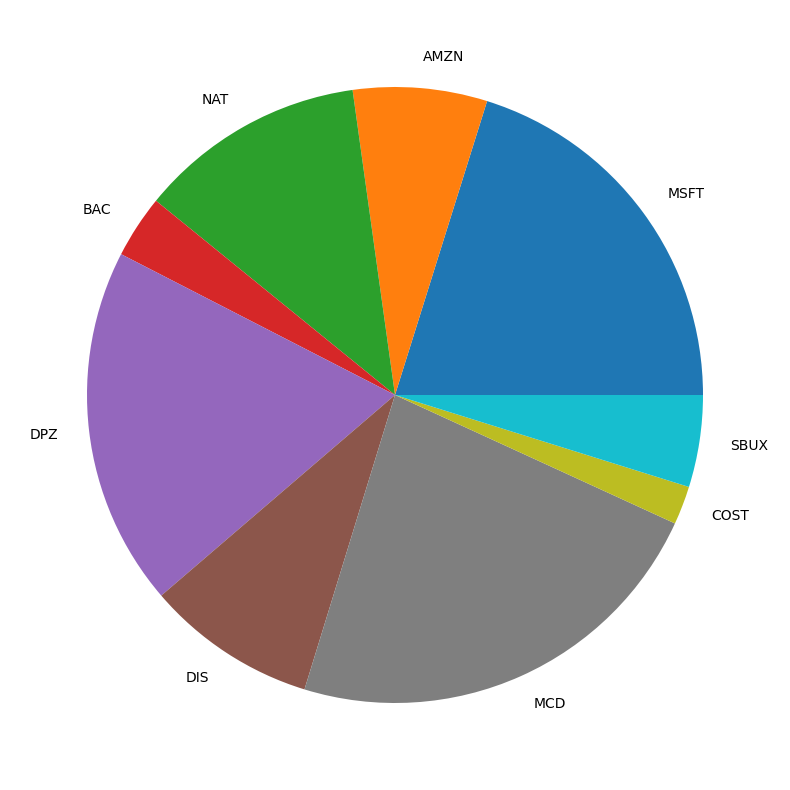

In [80]:
pd.Series(weights).plot.pie(figsize=(10,10));

In [81]:
from pypfopt import DiscreteAllocation

da = DiscreteAllocation(weights, prices.iloc[-1], total_portfolio_value=20000)
alloc, leftover = da.lp_portfolio()
print(f"Leftover: ${leftover:.2f}")
alloc

Leftover: $16.89


{'MSFT': 23,
 'AMZN': 3,
 'NAT': 4,
 'BAC': 1,
 'DPZ': 15,
 'DIS': 5,
 'MCD': 27,
 'COST': 6,
 'SBUX': 14}